In [1]:
from dotenv import load_dotenv
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from TabTransformer import run_experiment as run_experiment_c, infer_tabtransformer as infer_tabtransformer_c
from qCLSTabTransformer import run_experiment as run_experiment_q, infer_tabtransformer as infer_tabtransformer_q
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix, ConfusionMatrixDisplay

%load_ext autoreload
%autoreload 2

In [2]:
#Set up .env file with Kaggle API Token
load_dotenv()
os.environ["KAGGLE_API_TOKEN"] = os.getenv("KAGGLE_API_TOKEN")
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
file = os.path.join(path, 'creditcard.csv')
data = pd.read_csv(file)

print(f"# of Frauds = {np.sum(data['Class'])}")
print(np.sum(data['Class'])/len(data['Class'])*100, '%')

# of Frauds = 492
0.1727485630620034 %


In [3]:
#Split data into fraud and non-fraud to build high concentration of fraud in small training dataset
train_size = 2000
fraud_data = data[data['Class'] == 1].sample(frac=1, random_state=42)
non_fraud_data = data[data['Class'] == 0].sample(frac=1, random_state=42)
data_subset = pd.concat([fraud_data, non_fraud_data[:train_size - len(fraud_data)]]).sample(frac=1, random_state=42)

In [12]:
#Run classical experiment on small dataset
model_c, test_results_c, test_df = run_experiment_c(data_subset, lr=3e-3)
print(f'Classical model test AUPRC: {test_results_c["auprc"]}')

#Run quantum experiment on small dataset
model_q, test_results_q, test_df = run_experiment_q(data_subset, lr=3e-3)
print(f'Quantum CLS model test AUPRC: {test_results_q["auprc"]}')

Classical model test AUPRC: 0.9706291289885299
Quantum CLS model test AUPRC: 0.959575789402836


In [36]:
#Tabulate total parameters and training parameters to see model size
total_params_c = sum(p.numel() for p in model_c.parameters())
trainable_params_c = sum(p.numel() for p in model_c.parameters() if p.requires_grad)

print("Classical: ")
print(f"Total params: {total_params_c:,}")
print(f"Trainable params: {trainable_params_c:,}")

total_params_q = sum(p.numel() for p in model_q.parameters())
trainable_params_q = sum(p.numel() for p in model_q.parameters() if p.requires_grad)

print("\nQuantum: ")
print(f"Total params: {total_params_q:,}")
print(f"Trainable params: {trainable_params_q:,}")

Classical: 
Total params: 13,953
Trainable params: 13,953

Quantum: 
Total params: 14,249
Trainable params: 14,249


In [ ]:
#Gathers metrics for different inference sizes to see how well the models generalize
inference_sizes = [2000, 4000, 6000, 8000, 10000]
auprcs_c = []
auprcs_q = []
fraud_recalls_c = []
fraud_recalls_q = []
non_fraud_specificities_c = []
non_fraud_specificities_q = []
mean_scores_fraud_c = []
mean_scores_fraud_q = []
mean_scores_non_fraud_c = []
mean_scores_non_fraud_q = []

for size in inference_sizes:
    inference_df = pd.concat([test_df, non_fraud_data[train_size - len(fraud_data):train_size - len(fraud_data) + size - len(test_df)]]).sample(frac=1, random_state=42)

    #Classical model inference
    results = infer_tabtransformer_c(model_c, inference_df)
    fraud_preds_c = results['preds'][results['targets'] == 1]       #Collects predictions for true fraud data
    non_fraud_preds_c = results['preds'][results['targets'] == 0]   #Collects predictions for true non-fraud data
    fraud_scores_c = results['probs'][results['targets'] == 1]      #Collects scores for true fraud data
    non_fraud_scores_c = results['probs'][results['targets'] == 0]  #Collects scores for true non-fraud data

    auprcs_c.append(results['auprc'])
    fraud_recalls_c.append(np.sum(fraud_preds_c) / len(fraud_preds_c))                           #TP / (TP + FN)
    non_fraud_specificities_c.append(1 - np.sum(non_fraud_preds_c) / len(non_fraud_preds_c))     #TN / (TN + FP)
    mean_scores_fraud_c.append(np.mean(fraud_scores_c))               #Get mean probabilities to visualize separation between classes
    mean_scores_non_fraud_c.append(np.mean(non_fraud_scores_c))

    #Quantum model inference
    results = infer_tabtransformer_q(model_q, inference_df)
    fraud_preds_q = results['preds'][results['targets'] == 1]
    non_fraud_preds_q = results['preds'][results['targets'] == 0]
    fraud_scores_q = results['probs'][results['targets'] == 1]
    non_fraud_scores_q = results['probs'][results['targets'] == 0]

    auprcs_q.append(results['auprc'])
    fraud_recalls_q.append(np.sum(fraud_preds_q) / len(fraud_preds_q))
    non_fraud_specificities_q.append(1 - np.sum(non_fraud_preds_q) / len(non_fraud_preds_q))
    mean_scores_fraud_q.append(np.mean(fraud_scores_q))
    mean_scores_non_fraud_q.append(np.mean(non_fraud_scores_q))
    

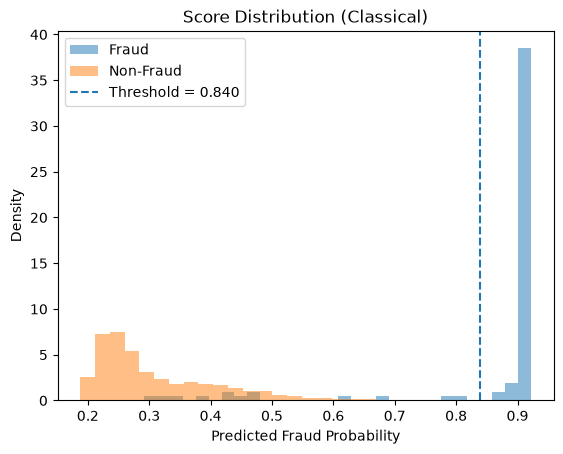

In [33]:
plt.hist(fraud_scores_c, bins=30, alpha=0.5, density=True, label="Fraud")
plt.hist(non_fraud_scores_c, bins=30, alpha=0.5, density=True, label="Non-Fraud")
plt.axvline(model_c.threshold, linestyle="--", label=f"Threshold = {model_c.threshold:.3f}")
plt.title("Score Distribution (Classical)")
plt.xlabel("Predicted Fraud Probability")
plt.ylabel("Density")
plt.legend()
plt.show()

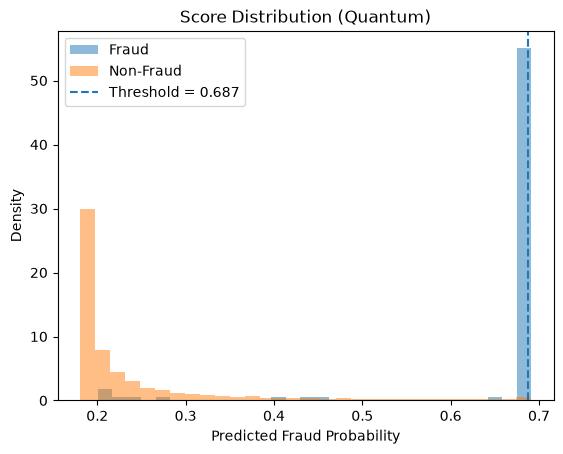

In [34]:
plt.hist(fraud_scores_q, bins=30, alpha=0.5, density=True, label="Fraud")
plt.hist(non_fraud_scores_q, bins=30, alpha=0.5, density=True, label="Non-Fraud")
plt.axvline(model_q.threshold, linestyle="--", label=f"Threshold = {model_q.threshold:.3f}")
plt.title("Score Distribution (Quantum)")
plt.xlabel("Predicted Fraud Probability")
plt.ylabel("Density")
plt.legend()
plt.show()

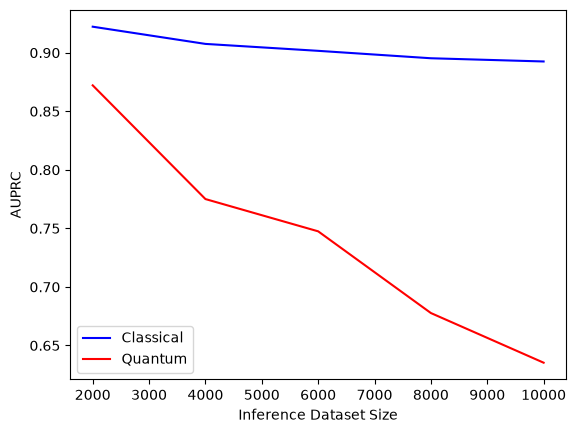

In [26]:
plt.plot(inference_sizes, auprcs_c, label="Classical", color='b')
plt.plot(inference_sizes, auprcs_q, label="Quantum", color='r')
plt.xlabel("Inference Dataset Size")
plt.ylabel("AUPRC")
plt.legend()
plt.show()

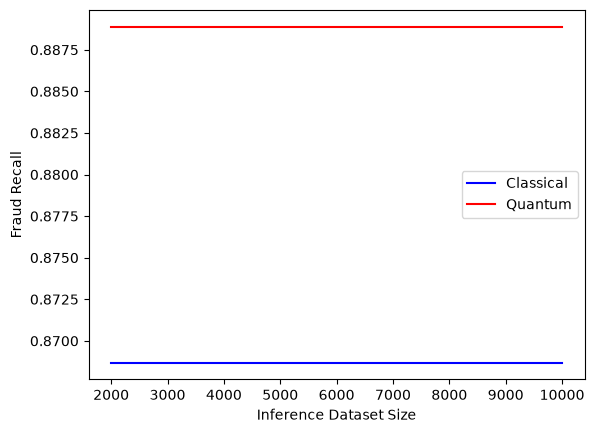

In [27]:
plt.plot(inference_sizes, fraud_recalls_c, label="Classical", color='b')
plt.plot(inference_sizes, fraud_recalls_q, label="Quantum", color='r')
plt.xlabel("Inference Dataset Size")
plt.ylabel("Fraud Recall")
plt.legend()
plt.show()

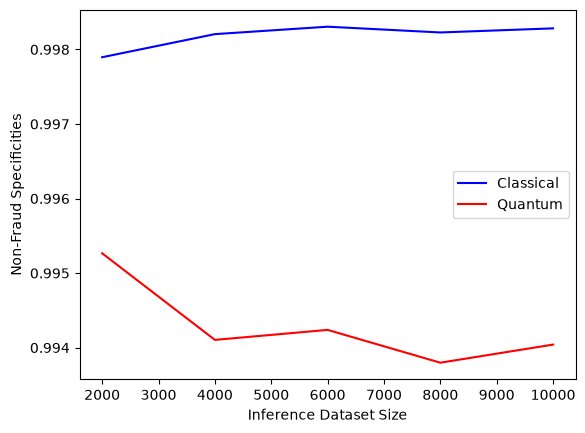

In [28]:
plt.plot(inference_sizes, non_fraud_specificities_c, label="Classical", color='b')
plt.plot(inference_sizes, non_fraud_specificities_q, label="Quantum", color='r')
plt.xlabel("Inference Dataset Size")
plt.ylabel("Non-Fraud Specificities")
plt.legend()
plt.show()

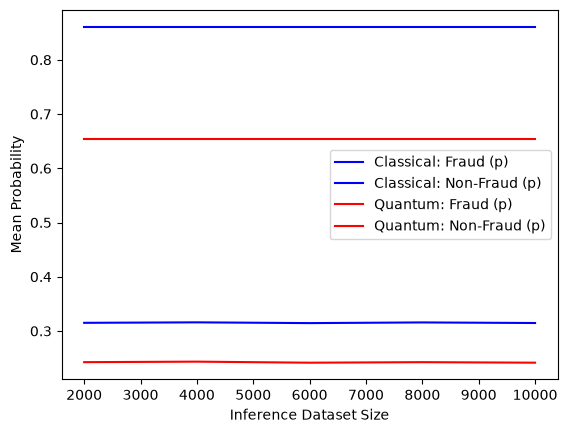

In [43]:
plt.plot(inference_sizes, mean_scores_fraud_c, label="Classical: Fraud (p)", color='b')
plt.plot(inference_sizes, mean_scores_non_fraud_c, label="Classical: Non-Fraud (p)", color='b')
plt.plot(inference_sizes, mean_scores_fraud_q, label="Quantum: Fraud (p)", color='r')
plt.plot(inference_sizes, mean_scores_non_fraud_q, label="Quantum: Non-Fraud (p)", color='r')
plt.xlabel("Inference Dataset Size")
plt.ylabel("Mean Probability")
plt.legend()
plt.show()

In [38]:
#Do train/val/test experiment on full dataset for visualization of key metrics
model, test_results, test_df = run_experiment_c(data, lr=7e-3)
print(f'Test AUPRC using full dataset in train/val/test experiment: {test_results_q["auprc"]}')

Test AUPRC using full dataset in train/val/test experiment: 0.959575789402836


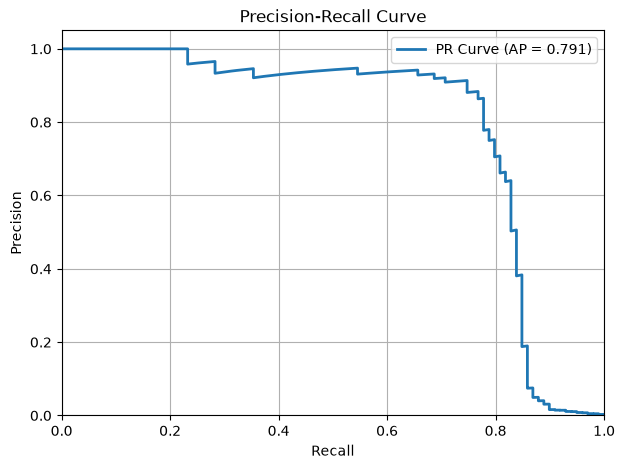

In [39]:
y_true = test_results['targets']
y_scores = test_results['probs']

precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

# Compute average precision (area under PR curve)
ap_score = average_precision_score(y_true, y_scores)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, linewidth=2, label=f"PR Curve (AP = {ap_score:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True)
plt.legend()
plt.show()

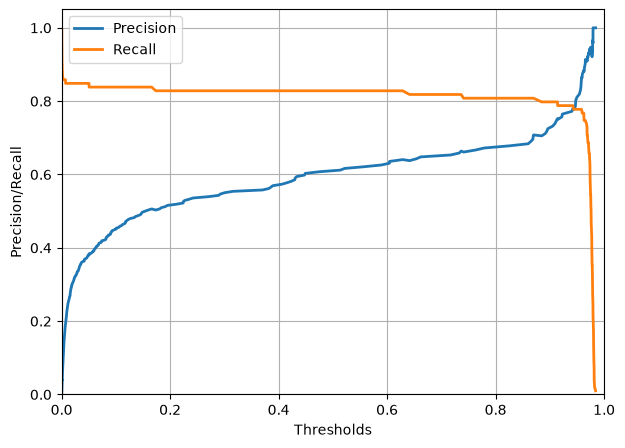

In [40]:
#Plot precision and recall vs decision threshold. Can use visual to optimize precision vs recall tradeoff and choose optimal decision threshold
plt.figure(figsize=(7, 5))
plt.plot(thresholds, precision[:-1], linewidth=2, label="Precision")
plt.plot(thresholds, recall[:-1], linewidth=2, label="Recall")
plt.xlabel("Thresholds")
plt.ylabel("Precision/Recall")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend()
plt.grid(True)
plt.show()

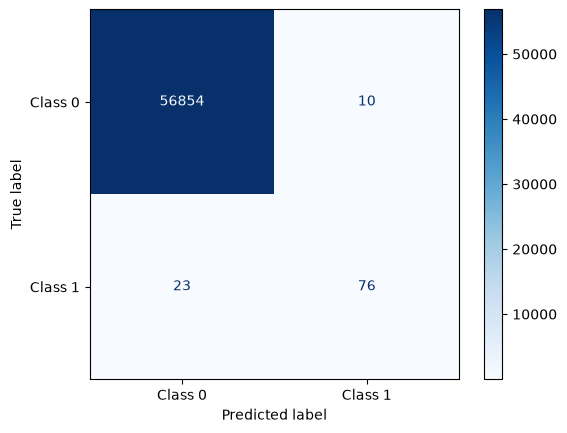

In [42]:
#Displays confusion matrix from testing results
threshold = model.threshold
cm = confusion_matrix(y_true, (y_scores >= threshold).astype(int))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues)
plt.show()